# Customer Segmentation Using Unsupervised Learning

## Objective
The objective of this project is to segment customers based on their annual income and spending behavior using K-Means Clustering. The project also aims to provide useful marketing strategies for each identified customer group.

In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset Loading

In this step, we load the Mall Customers dataset and check the first few rows of the dataset.

In [6]:
import pandas as pd

url = "https://storage.googleapis.com/kagglesdsdata/datasets/98271/234637/Mall_Customers.csv"

df = pd.read_csv("Mall_Customers.csv")

print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


# Dataset Information

Now we will explore the dataset structure, data types, and missing values.

In [7]:
# Dataset Information

print(df.info())

print("\nMissing Values:\n")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

Missing Values:

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


# Exploratory Data Analysis (EDA)

We will visualize customer data to better understand spending behavior and income distribution.

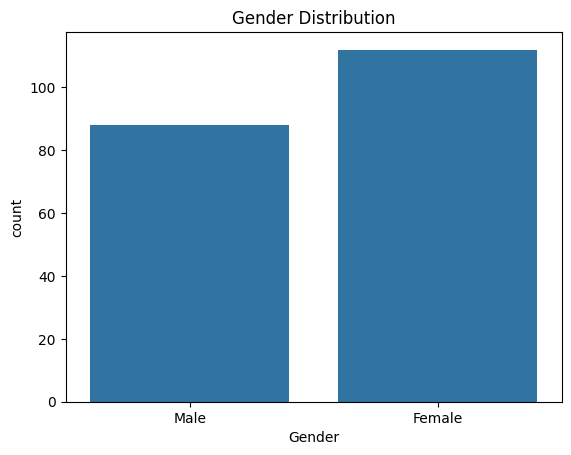

In [8]:
# Gender Distribution

sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()

# Elbow Method

The Elbow Method helps us find the optimal number of clusters for K-Means Clustering.

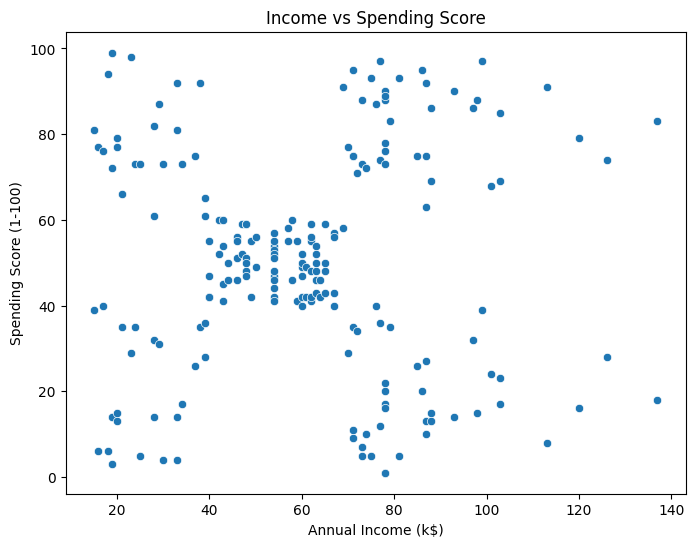

In [9]:
# Annual Income vs Spending Score

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")
plt.show()

# Feature Selection

We will use Annual Income and Spending Score for customer segmentation.

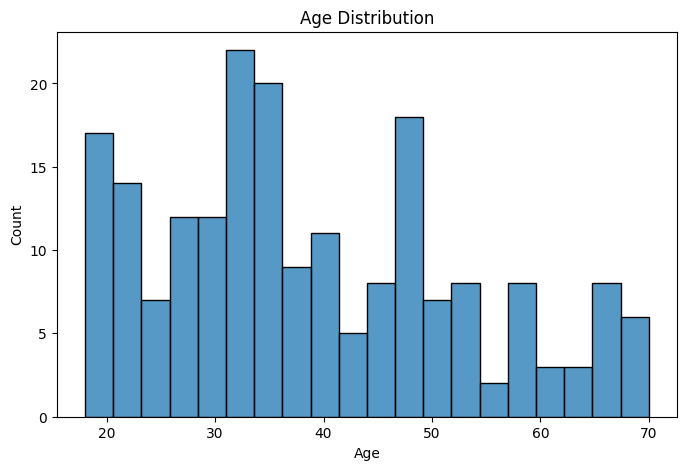

In [10]:
# Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title("Age Distribution")
plt.show()

# K-Means Clustering

Based on the Elbow Method, we apply K-Means Clustering with 5 clusters.

In [11]:
# Select Features

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Cluster Visualization

Now we visualize the customer segments generated by K-Means Clustering.

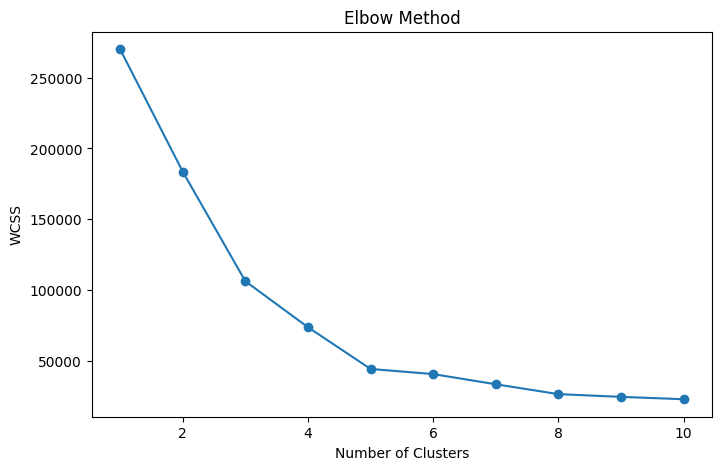

In [12]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

# Plot Elbow Graph

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

# PCA Visualization

Principal Component Analysis (PCA) is used to reduce dimensions and visualize clusters more clearly.

In [13]:
# Apply K-Means

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

y_kmeans = kmeans.fit_predict(X)

# Marketing Strategies for Customer Segments

Different marketing strategies can be designed for each customer group.

In [14]:
# Add Cluster Column

df['Cluster'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Suggested Marketing Strategies

| Cluster Type | Marketing Strategy |
|---|---|
| High Income + High Spending | Premium products and VIP offers |
| Low Income + Low Spending | Discounts and promotions |
| High Income + Low Spending | Personalized recommendations |
| Young High Spenders | Trend-based advertising |
| Average Customers | Loyalty and membership programs |

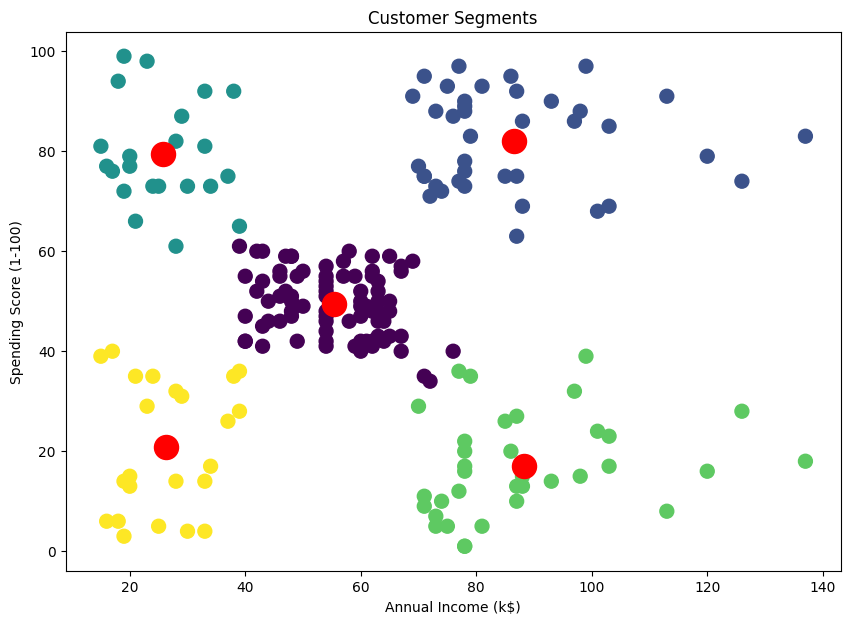

In [15]:
# Visualize Clusters

plt.figure(figsize=(10,7))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    s=100
)

# Cluster Centers

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red'
)

plt.title("Customer Segments")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.show()

# Conclusion

In this project, K-Means Clustering was successfully used to segment customers based on income and spending patterns. PCA visualization helped in understanding customer groups more effectively. These customer insights can help businesses improve their marketing strategies and decision-making process.

In [16]:
from sklearn.decomposition import PCA

In [17]:
# Apply PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

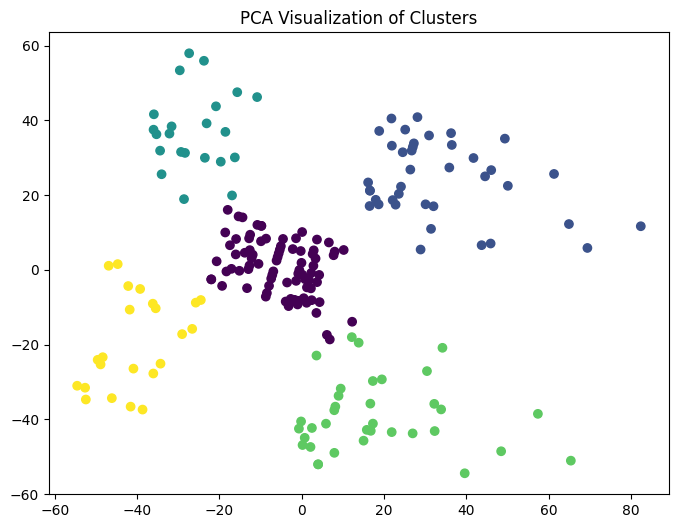

In [18]:
# PCA Scatter Plot

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y_kmeans
)

plt.title("PCA Visualization of Clusters")

plt.show()

In [19]:
# Display Average Values per Cluster

cluster_summary = df.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

print(cluster_summary)

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043
